In [ ]:
'''
Since we know that Markov Property states: the furture state depends only on the current state, not the history.
Agar transition matrix valid hai (irreducible + aperiodic), toh chahe kisi bhi method se nikalo — answer converge karega ek unique stationary distribution par.
'''

In [ ]:
'''
I will have to build a fully connected graph like I choosed
my states to be sunny, rainy and cloudy.
I will have to build a graph with 3 nodes and each node will have 3 edges to itself and the other two nodes.
I will have to assign probabilities to each edge such that the sum of the probabilities of the edges coming out of a node is 1.
'''

In [1]:
states=['Sunny','Rainy','Cloudy']

Transition_Matrix=[[0.7,0.2,0.1],
                   [0.3,0.4,0.3],
                   [0.2,0.3,0.5]]



In [2]:
'''Yaha pe mera harek row ka sum exactly 1.0 hai.
Jaise ki pehle row me 0.7+0.2+0.1=1.0,
dusre row me 0.3+0.4+0.3=1.0,
teesre row me 0.2+0.3+0.5=1.0'''

'Yaha pe mera harek row ka sum exactly 1.0 hai.\nJaise ki pehle row me 0.7+0.2+0.1=1.0,\ndusre row me 0.3+0.4+0.3=1.0,\nteesre row me 0.2+0.3+0.5=1.0'

In [3]:
'''Since this is a sampling approach, I will have to pick an initial state 
and then I will have to use the transition matrix to pick the next state based on the probabilities.'''

'''Basically state uthao, phir for each day, look at the current state's row in Transition_Matrix, and then use the probabilities in that row to randomly select the next state. Repeat this process for as many days as you want to simulate.
Sample the next state using those probabilities(like a rolling wieghted die)
record the state, repeat for 10k steps as hum 10,000 days ke liye krrhe hai 
Phir count kro ki kitna din hai teeno mein each 
Divide each count by 10,000 to get the probabilities of being in each state after 10,000 days->your empicircal stationary distribution''
'''

import numpy as np 
import random 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


In [4]:
T=np.array(Transition_Matrix)

In [5]:
T.shape

(3, 3)

In [6]:
assert np.allclose(T.sum(axis=1),1.0)

In [7]:
print(f"{'':10}", "  ".join(f"{s:>8}" for s in states))

              Sunny     Rainy    Cloudy


In [24]:
from collections import defaultdict
mpp=defaultdict(int)

In [25]:
def monte_carlo(T,num_days=10000,start_state=0):
    '''
    Simulate num_days using weighted random sampling based on the transition matrix T, starting from start_state.
    '''
    vis=[start_state]
    mpp[start_state]+=1
    current=start_state

    for _ in range(num_days+1):
        current=np.random.choice(len(states),p=T[current])
        vis.append(current)
        mpp[current]+=1
    
    return np.array(vis)

In [26]:
np.random.seed(42)
# mpp=defaultdict(int)
simulation=monte_carlo(T,num_days=10000,start_state=0)

In [27]:
'''
Emprical Stationary Distribution:
Count the number of times each state is visited in the simulation and divide by the total number of days to get the empirical probabilities of being in each state after 10,000 days.
'''
#since we have 3 states so simply map ka use krlenge 
counts=np.bincount(simulation, minlength=3)
mc_distribution=counts/len(simulation)
print(counts,mc_distribution)

[4690 2823 2489] [0.46890622 0.28224355 0.24885023]


In [29]:
print(mpp[0],mpp[1],mpp[2])
#I have used numpy like can be easily done via map too but thik hai.....

4690 2823 2489


In [30]:
for i,s in enumerate(states):
    print(f"Empirical probability of being in state {s} after 10,000 days: {mc_distribution[i]:.4f}")

Empirical probability of being in state Sunny after 10,000 days: 0.4689
Empirical probability of being in state Rainy after 10,000 days: 0.2822
Empirical probability of being in state Cloudy after 10,000 days: 0.2489


In [31]:
'''Distrbiution of states over time:
Plot the distribution of states over time to see how it evolves and whether it converges to a stationary distribution.
'''

def evolve_distribution(T, pi_0, steps=100):
    """
    π_{t+1} = π_t @ T
    Track how the distribution changes over time.
    """
    pi=pi_0.copy()
    history=[pi.copy()]
    for _ in range(steps):
        pi=pi@T
        history.append(pi.copy())
    return np.array(history)

In [32]:
pi_0=np.array([1.0, 0.0, 0.0]) #because i have choosed sunny as my starting state
history=evolve_distribution(T, pi_0, steps=50)

In [34]:
print("\n📈 Distribution evolution (first 6 steps):")
print(f"{'Step':>6}", "  ".join(f"{s:>8}" for s in states))
for t in [0, 1, 2, 5, 10, 20, 50]:
    row = history[t]
    print(f"{t:>6}", "  ".join(f"{v:8.4f}" for v in row))



📈 Distribution evolution (first 6 steps):
  Step    Sunny     Rainy    Cloudy
     0   1.0000    0.0000    0.0000
     1   0.7000    0.2000    0.1000
     2   0.5700    0.2500    0.1800
     5   0.4685    0.2794    0.2521
    10   0.4568    0.2825    0.2607
    20   0.4565    0.2826    0.2609
    50   0.4565    0.2826    0.2609


In [36]:
'''Power Iteration'''
def matrix_power(T, n):
    """Fast matrix exponentiation: T^n"""
    result = np.eye(len(T))
    base = T.copy()
    while n > 0:
        if n % 2 == 1:
            result = result @ base
        base = base @ base
        n //= 2
    return result

Tn = matrix_power(T, 1000)
power_iter_dist = Tn[0]  # All rows converge to same vector

print("\nPower Iteration (T^1000),row 0:")
for i, s in enumerate(states):
    print(f"  {s:8}: {power_iter_dist[i]:.6f}")


Power Iteration (T^1000),row 0:
  Sunny   : 0.456522
  Rainy   : 0.282609
  Cloudy  : 0.260870


In [40]:
'''Analytical Solution'''
def analytic_steady_state(T):
    """
    Solve π T = π  subject to  Σπ = 1
    Rewrite as linear system A @ π = b
    Replace last equation with normalization constraint.
    """
    n = len(T)
    # (T^T - I) @ π = 0  → build coefficient matrix
    A = (T.T - np.eye(n))
    # Replace last row with normalization: sum of π = 1
    A[-1, :] = 1.0
    b = np.zeros(n)
    b[-1] = 1.0
    pi_star = np.linalg.solve(A, b)
    return pi_star

analytic_dist = analytic_steady_state(T)

print("\nAnalytic Steady State (eigenvector method):")
for i, s in enumerate(states):
    print(f"  {s:8}: {analytic_dist[i]:.6f}")


Analytic Steady State (eigenvector method):
  Sunny   : 0.456522
  Rainy   : 0.282609
  Cloudy  : 0.260870


In [41]:
print("\n" + "="*55)
print(f"{'Method':<22}", "  ".join(f"{s:>8}" for s in states))
print("="*55)
print(f"{'Monte Carlo':<22}", "  ".join(f"{v:8.4f}" for v in mc_distribution))
print(f"{'Power Iteration':<22}", "  ".join(f"{v:8.4f}" for v in power_iter_dist))
print(f"{'Analytic':<22}", "  ".join(f"{v:8.4f}" for v in analytic_dist))
print("="*55)


Method                    Sunny     Rainy    Cloudy
Monte Carlo              0.4689    0.2822    0.2489
Power Iteration          0.4565    0.2826    0.2609
Analytic                 0.4565    0.2826    0.2609


In [42]:
COLORS = ["#f5a623", "#7b8fa1", "#4a90d9"]


 Plot saved to weather_markov_results.png


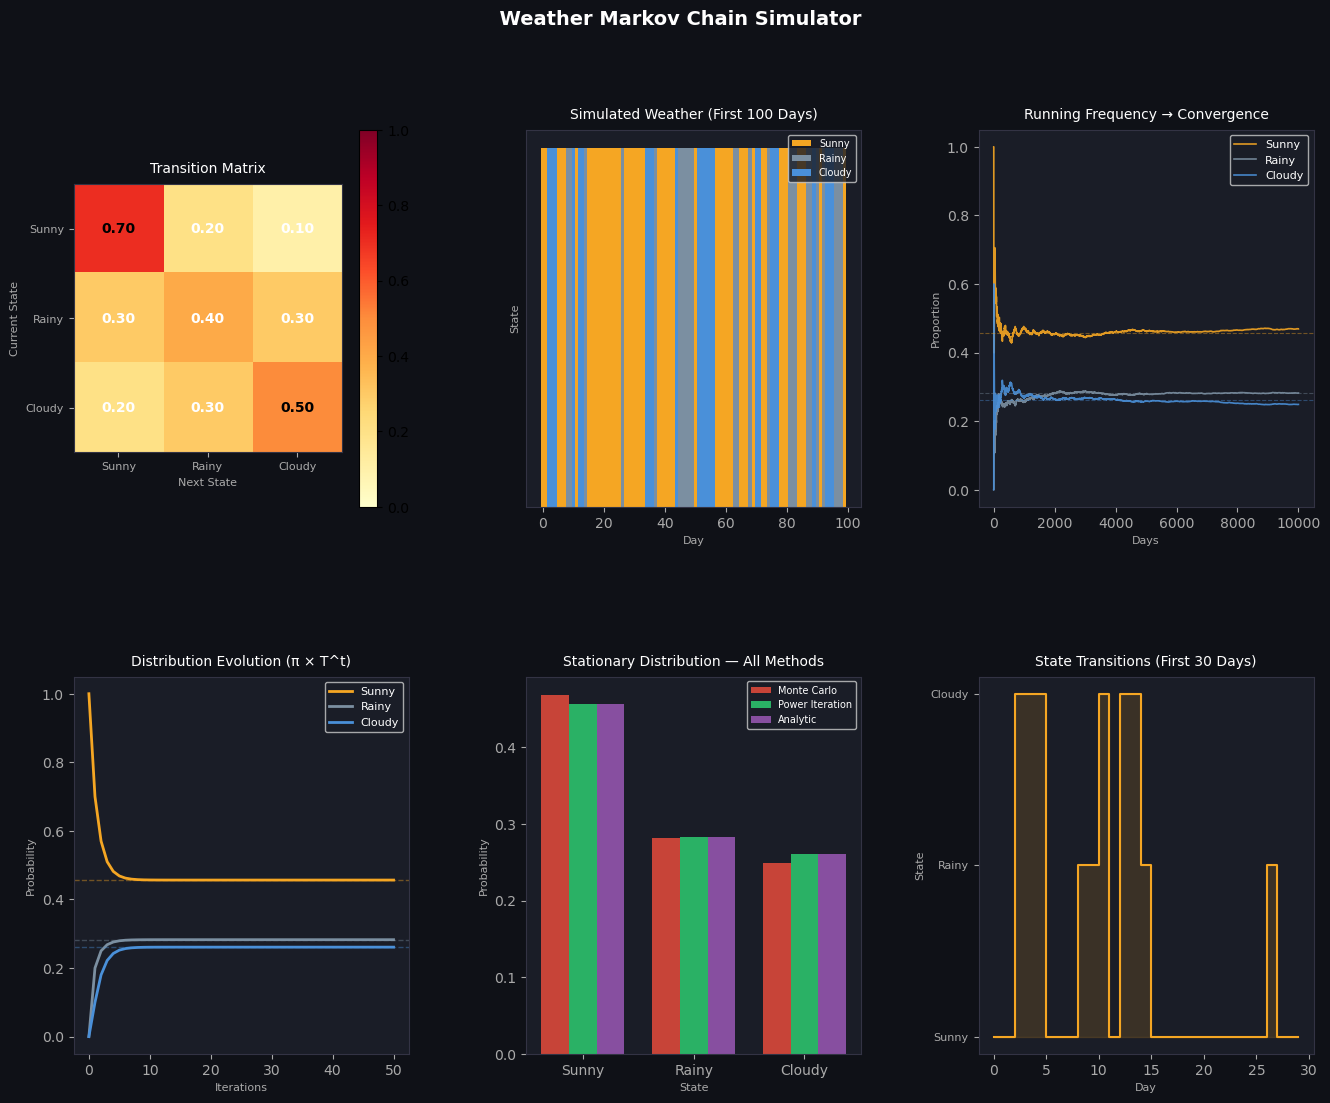

In [45]:
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("#0f1117")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

def style_ax(ax, title, xlabel, ylabel):
    ax.set_facecolor("#1a1d27")
    ax.set_title(title, color="white", fontsize=10, pad=8)
    ax.set_xlabel(xlabel, color="#aaaaaa", fontsize=8)
    ax.set_ylabel(ylabel, color="#aaaaaa", fontsize=8)
    ax.tick_params(colors="#aaaaaa")
    for spine in ax.spines.values():
        spine.set_edgecolor("#333344")

# Plot 1: Transition matrix heatmap
im = ax1.imshow(T, cmap="YlOrRd", vmin=0, vmax=1)
ax1.set_xticks(range(3)); ax1.set_yticks(range(3))
ax1.set_xticklabels(states, color="white", fontsize=8)
ax1.set_yticklabels(states, color="white", fontsize=8)
for i in range(3):
    for j in range(3):
        ax1.text(j, i, f"{T[i,j]:.2f}", ha="center", va="center",
                 color="black" if T[i,j] > 0.4 else "white", fontsize=10, fontweight="bold")
style_ax(ax1, "Transition Matrix", "Next State", "Current State")
plt.colorbar(im, ax=ax1)

# Plot 2: First 100 days simulation
days_shown = 100
day_colors = [COLORS[s] for s in simulation[:days_shown]]
ax2.bar(range(days_shown), [1]*days_shown, color=day_colors, width=1.0)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS[i], label=states[i]) for i in range(3)]
ax2.legend(handles=legend_elements, loc="upper right", fontsize=7,
           facecolor="#1a1d27", labelcolor="white")
style_ax(ax2, "Simulated Weather (First 100 Days)", "Day", "State")
ax2.set_yticks([])

# Plot 3: Running frequency (convergence over time)
running = np.array([
    np.cumsum(simulation == i) / (np.arange(len(simulation)) + 1)
    for i in range(3)
])
for i in range(3):
    ax3.plot(running[i], color=COLORS[i], label=states[i], linewidth=1.2, alpha=0.9)
for i in range(3):
    ax3.axhline(analytic_dist[i], color=COLORS[i], linestyle="--", alpha=0.4, linewidth=0.8)
ax3.legend(fontsize=8, facecolor="#1a1d27", labelcolor="white")
style_ax(ax3, "Running Frequency → Convergence", "Days", "Proportion")

# Plot 4: Distribution evolution π_t over iterations
for i in range(3):
    ax4.plot(history[:, i], color=COLORS[i], label=states[i], linewidth=2)
for i in range(3):
    ax4.axhline(analytic_dist[i], color=COLORS[i], linestyle="--", alpha=0.4, linewidth=1)
ax4.legend(fontsize=8, facecolor="#1a1d27", labelcolor="white")
style_ax(ax4, "Distribution Evolution (π × T^t)", "Iterations", "Probability")

# Plot 5: Final comparison bar chart
x = np.arange(3)
w = 0.25
ax5.bar(x - w, mc_distribution,    width=w, label="Monte Carlo",     color="#e74c3c", alpha=0.85)
ax5.bar(x,     power_iter_dist,    width=w, label="Power Iteration", color="#2ecc71", alpha=0.85)
ax5.bar(x + w, analytic_dist,      width=w, label="Analytic",        color="#9b59b6", alpha=0.85)
ax5.set_xticks(x); ax5.set_xticklabels(states, color="white")
ax5.legend(fontsize=7, facecolor="#1a1d27", labelcolor="white")
style_ax(ax5, "Stationary Distribution — All Methods", "State", "Probability")

# Plot 6: State transition over 30 days (step plot)
sample = simulation[:30]
ax6.step(range(30), sample, where="post", color="#f5a623", linewidth=1.5)
ax6.set_yticks([0, 1, 2]); ax6.set_yticklabels(states, color="white", fontsize=8)
ax6.fill_between(range(30), sample, step="post", alpha=0.15, color="#f5a623")
style_ax(ax6, "State Transitions (First 30 Days)", "Day", "State")

fig.suptitle("  Weather Markov Chain Simulator", color="white",
             fontsize=14, fontweight="bold", y=0.98)

plt.savefig("weather_markov_results.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print("\n Plot saved to weather_markov_results.png")
plt.show()